# OASIS Alzheimer's Classification — SHAP Explainability

**Goal:** Explain the single **best-performing model** identified in `OASIS_Baseline_Models.ipynb` — **Random Forest** (highest AUROC = 0.942 among all 11 models evaluated, including the Hybrid Ensemble).

This notebook does **not** retrain, tune, or compare models (the one exception is the feature ablation study in Section 8, which by definition requires refitting the model with one feature removed at a time — no other section touches the model's training). It reuses the exact same preprocessing pipeline, train/test split, and hyperparameters as the baseline notebook, and focuses only on interpreting the model's behavior via SHAP, permutation importance, partial dependence, and ablation.

**Note on "loading" the trained model.** The baseline notebook does not persist a serialized model file (e.g. `.pkl`) between notebooks, so there is no artifact to load from disk. To obtain the exact same fitted Random Forest in memory, this notebook reconstructs it using the **identical code, data, preprocessing, split, and `random_state=42`** as the baseline notebook — this is fully deterministic and reproduces the same fitted model, not a new training run with different data or hyperparameters. The sanity check in Section 2 confirms the reconstructed model's test-set metrics match the baseline notebook's reported numbers exactly.

In [1]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
shap.initjs()

## 1. Load Data & Reuse the Baseline Preprocessing Pipeline / Train-Test Split

In [3]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)

def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)
df = df[df["Group"] != "Unknown"].reset_index(drop=True)  # drop subjects with no diagnosis

# Impute the few legitimately missing clinical fields (median)
for col in ["Educ", "SES", "MMSE"]:
    df[col] = df[col].fillna(df[col].median())

# Encode
df["Gender"] = df["M/F"].map({"M": 0, "F": 1})
df["Target"] = df["Group"].map({"Nondemented": 0, "Demented": 1})

# Feature set: biomarkers/demographics only -- CDR is excluded (label leakage)
FEATURES = ["Age", "Gender", "Educ", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
CLASS_NAMES = ["Nondemented", "Demented"]

X = df[FEATURES]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (188, 8), Test: (47, 8)


## 2. Reconstruct the Best Model (Random Forest) — No Hyperparameter Changes

In [4]:
best_model = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Sanity check against baseline notebook's reported Table 1A row for Random Forest:")
print(f"  Accuracy = {accuracy_score(y_test, y_pred):.3f}  (baseline: 0.830)")
print(f"  F1       = {f1_score(y_test, y_pred):.3f}  (baseline: 0.778)")
print(f"  MCC      = {matthews_corrcoef(y_test, y_pred):.3f}  (baseline: 0.653)")
print(f"  AUROC    = {roc_auc_score(y_test, y_proba):.3f}  (baseline: 0.942)")

Sanity check against baseline notebook's reported Table 1A row for Random Forest:
  Accuracy = 0.830  (baseline: 0.830)
  F1       = 0.778  (baseline: 0.778)
  MCC      = 0.653  (baseline: 0.653)
  AUROC    = 0.942  (baseline: 0.942)


## 3. SHAP Summary Plot (Beeswarm)

Each point is one test-set subject; color encodes the feature's value (red = high, blue = low), and horizontal position shows the SHAP value's push toward *Demented* (right) or *Nondemented* (left).

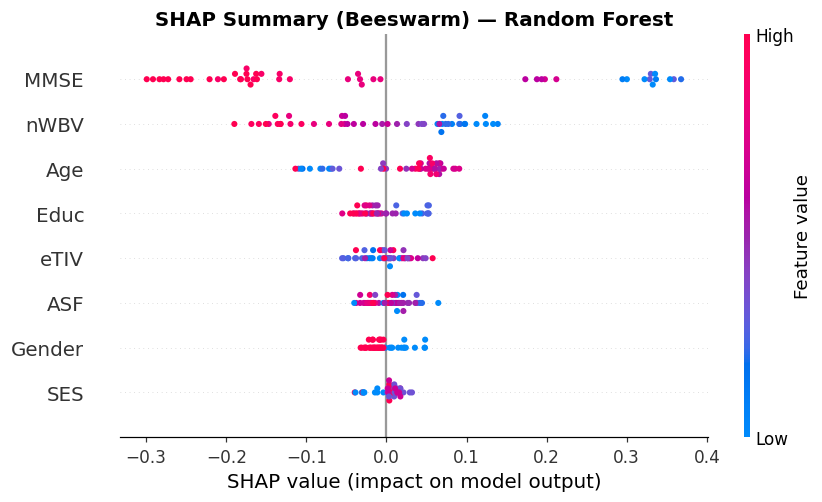

In [5]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# For binary classification, keep the SHAP values for the positive class (Demented)
if shap_values.values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_pos, X_test, feature_names=FEATURES, show=False)
plt.title("SHAP Summary (Beeswarm) — Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. SHAP Feature Importance (Bar Plot)

Mean absolute SHAP value per feature — an overall ranking of how much each clinical/demographic variable moves the model's predictions, regardless of direction.

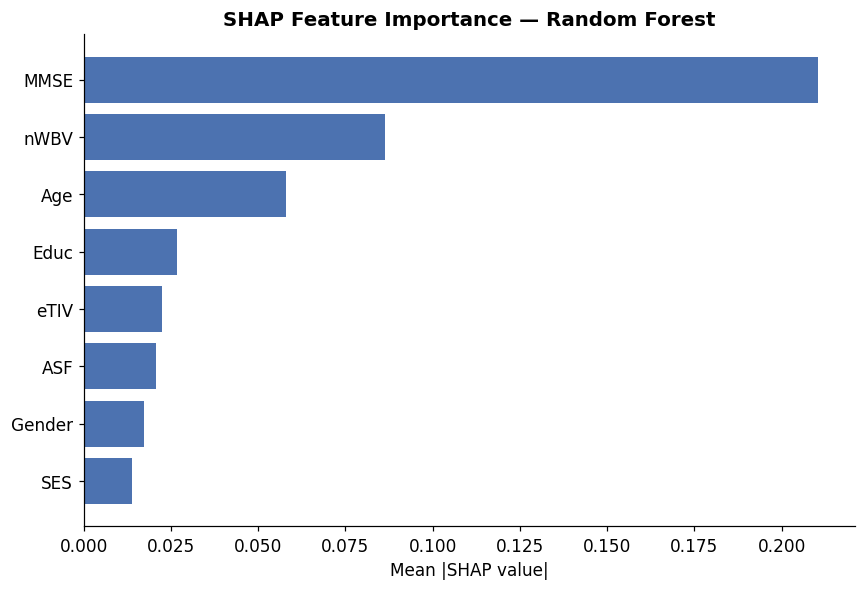

MMSE      0.210425
nWBV      0.086439
Age       0.057966
Educ      0.026625
eTIV      0.022349
ASF       0.020800
Gender    0.017156
SES       0.013940
dtype: float64

In [6]:
mean_abs_shap = pd.Series(
    np.abs(shap_values_pos.values).mean(axis=0), index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color="#4C72B0")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

mean_abs_shap.sort_values(ascending=False)

## 5. SHAP Waterfall Plot — One Correctly Predicted Sample

Shows how each feature pushes a single subject's prediction away from the model's base (expected) value toward the final predicted probability. We select a correctly predicted *Demented* case, since correctly identifying true positive dementia cases is the primary clinical use case.

Selected test-set row index (positional): 1
True label: Demented, Predicted: Demented, P(Demented) = 0.830


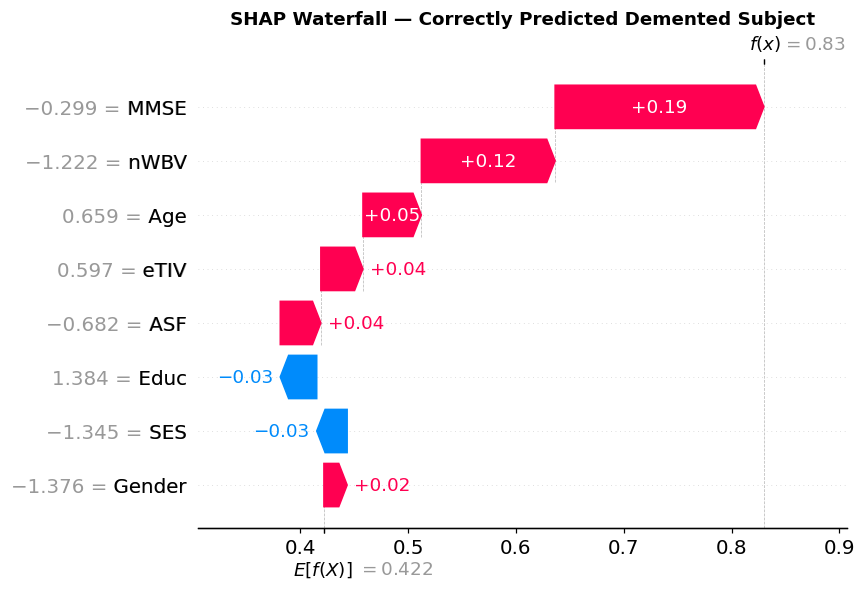

In [7]:
correct_mask = (y_pred == y_test.values) & (y_test.values == 1)
sample_idx = np.where(correct_mask)[0][0]  # first correctly predicted Demented case

print(f"Selected test-set row index (positional): {sample_idx}")
print(f"True label: {CLASS_NAMES[y_test.values[sample_idx]]}, "
      f"Predicted: {CLASS_NAMES[y_pred[sample_idx]]}, "
      f"P(Demented) = {y_proba[sample_idx]:.3f}")

fig = plt.figure(figsize=(9, 5.5))
shap.plots.waterfall(shap_values_pos[sample_idx], show=False)
plt.title("SHAP Waterfall — Correctly Predicted Demented Subject", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. SHAP Force Plot

A compact, single-row view of the same sample's SHAP contributions (matplotlib-rendered so it displays as a static, publication-quality figure).

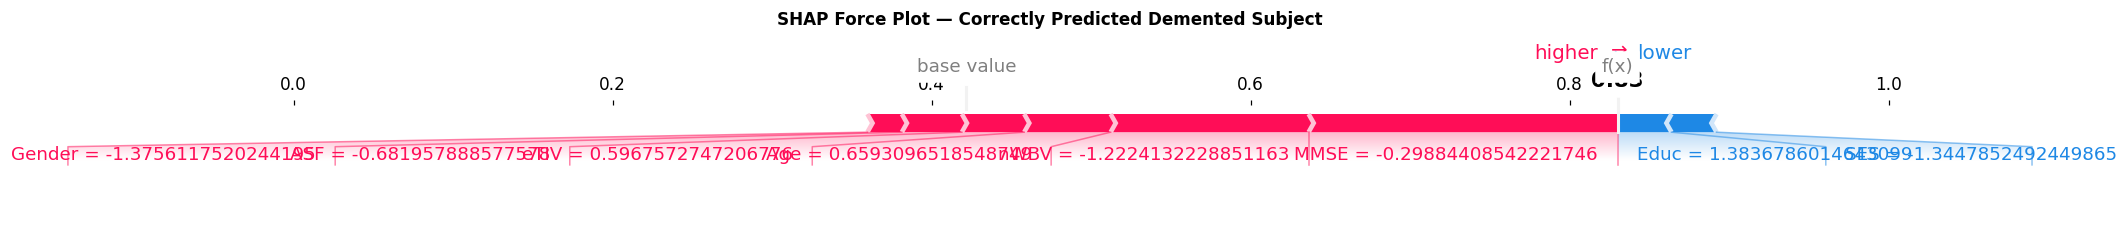

In [8]:
shap.plots.force(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_values_pos.values[sample_idx],
    features=X_test.iloc[sample_idx],
    feature_names=FEATURES,
    matplotlib=True,
    show=False,
)
plt.title("SHAP Force Plot — Correctly Predicted Demented Subject", fontsize=11, fontweight="bold", y=1.6)
plt.tight_layout()
plt.show()

## 7. Permutation Feature Importance

Measures the drop in AUROC on the test set when a single feature's values are randomly shuffled, breaking its relationship with the target. Unlike SHAP (which explains the model's internal logic), this is a model-agnostic, outcome-based importance measure.

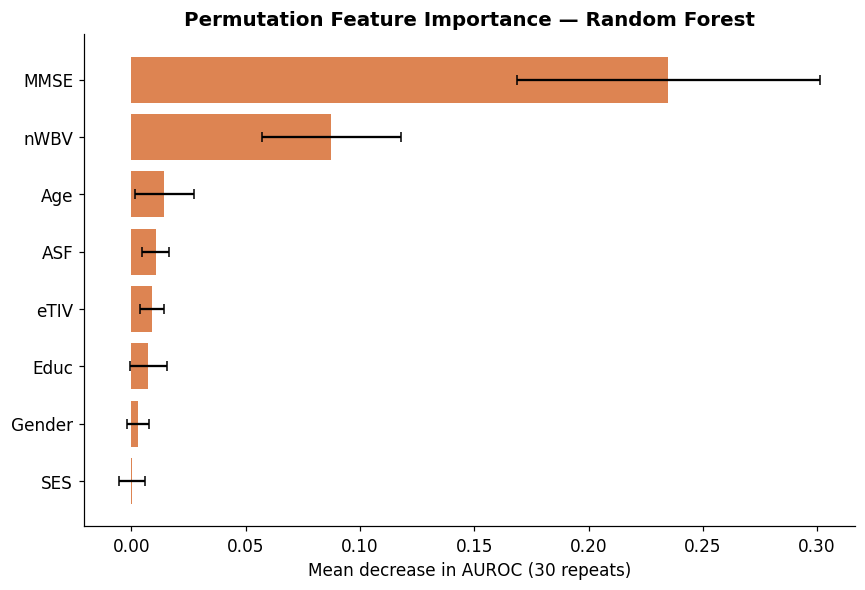

MMSE      0.234969
nWBV      0.087469
Age       0.014444
ASF       0.010617
eTIV      0.009167
Educ      0.007531
Gender    0.002840
SES       0.000370
dtype: float64

In [9]:
perm_result = permutation_importance(
    best_model, X_test, y_test, scoring="roc_auc",
    n_repeats=30, random_state=RANDOM_STATE
)

perm_importance = pd.Series(
    perm_result.importances_mean, index=FEATURES
).sort_values(ascending=True)
perm_std = pd.Series(perm_result.importances_std, index=FEATURES)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(perm_importance.index, perm_importance.values,
        xerr=perm_std.loc[perm_importance.index], color="#DD8452", capsize=3)
ax.set_xlabel("Mean decrease in AUROC (30 repeats)")
ax.set_title("Permutation Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

perm_importance.sort_values(ascending=False)

## 8. SHAP vs. Permutation Importance — Ranking Comparison

In [10]:
rank_comparison = pd.DataFrame({
    "SHAP Rank": mean_abs_shap.sort_values(ascending=False).index,
    "Permutation Rank": perm_importance.sort_values(ascending=False).index,
})
rank_comparison.index = rank_comparison.index + 1
rank_comparison.index.name = "Rank"
rank_comparison

,SHAP Rank,Permutation Rank
Rank,,
1,MMSE,MMSE
2,nWBV,nWBV
3,Age,Age
4,Educ,ASF
5,eTIV,eTIV
6,ASF,Educ
7,Gender,Gender
8,SES,SES


## 9. Partial Dependence Plots — Top 3 Features

PDPs show the model's *average* predicted probability of Demented as one feature varies, holding all others at their observed distribution. Top 3 features are taken from the SHAP importance ranking above.

Top 3 features (by mean |SHAP value|): ['MMSE', 'nWBV', 'Age']


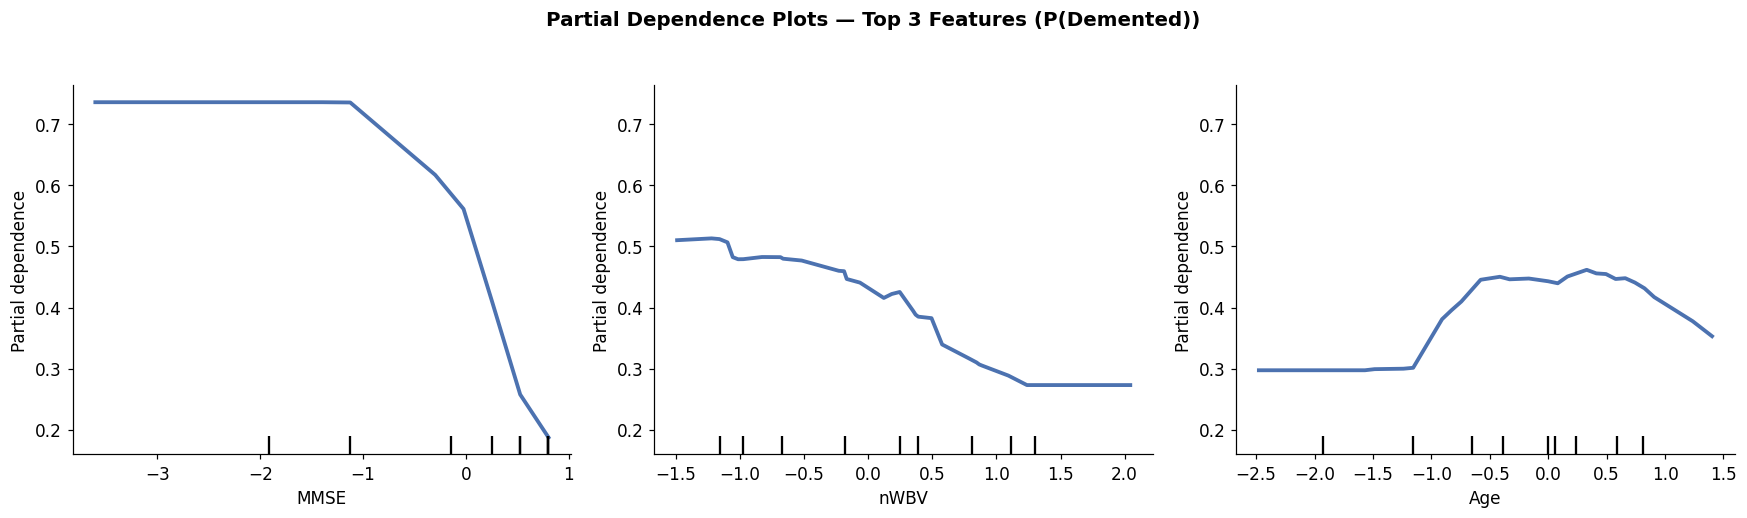

In [11]:
top3_features = mean_abs_shap.sort_values(ascending=False).index[:3].tolist()
print("Top 3 features (by mean |SHAP value|):", top3_features)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=top3_features,
    target=1, ax=ax, line_kw={"color": "#4C72B0", "linewidth": 2.5}
)
fig.suptitle("Partial Dependence Plots — Top 3 Features (P(Demented))", y=1.04, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Feature Ablation Study

For each feature, remove it from the training and test sets, refit a Random Forest with the **same hyperparameters** (`n_estimators=200`, `random_state=42`) on the remaining features, and evaluate on the corresponding reduced test set. This isolates each feature's marginal contribution to the fitted model's predictive performance — it is the only retraining step in this notebook, and it retrains the same model type/hyperparameters, not a different model.

In [12]:
ablation_rows = []

# Full-feature model, for reference
ablation_rows.append({
    "Removed Feature": "(none — full model)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Macro F1": f1_score(y_test, y_pred, average="macro"),
    "MCC": matthews_corrcoef(y_test, y_pred),
    "AUROC": roc_auc_score(y_test, y_proba),
})

for feat in FEATURES:
    reduced_features = [f for f in FEATURES if f != feat]
    X_train_reduced = X_train[reduced_features]
    X_test_reduced = X_test[reduced_features]

    model_reduced = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
    model_reduced.fit(X_train_reduced, y_train)

    y_pred_r = model_reduced.predict(X_test_reduced)
    y_proba_r = model_reduced.predict_proba(X_test_reduced)[:, 1]

    ablation_rows.append({
        "Removed Feature": feat,
        "Accuracy": accuracy_score(y_test, y_pred_r),
        "Macro F1": f1_score(y_test, y_pred_r, average="macro"),
        "MCC": matthews_corrcoef(y_test, y_pred_r),
        "AUROC": roc_auc_score(y_test, y_proba_r),
    })

ablation_table = pd.DataFrame(ablation_rows).set_index("Removed Feature").round(3)

# Drop in AUROC relative to the full model, as the primary ranking criterion
ablation_table["AUROC Drop"] = (ablation_table.loc["(none — full model)", "AUROC"] - ablation_table["AUROC"]).round(3)
ablation_table = pd.concat([
    ablation_table.loc[["(none — full model)"]],
    ablation_table.drop("(none — full model)").sort_values("AUROC Drop", ascending=False)
])
ablation_table

,Accuracy,Macro F1,MCC,AUROC,AUROC Drop
Removed Feature,,,,,
(none — full model),0.830,0.820,0.653,0.942,0.000
MMSE,0.787,0.785,0.573,0.863,0.079
nWBV,0.851,0.841,0.703,0.899,0.043
Age,0.872,0.865,0.744,0.934,0.008
ASF,0.809,0.799,0.606,0.935,0.007
SES,0.830,0.823,0.650,0.937,0.005
Educ,0.851,0.844,0.696,0.941,0.001
Gender,0.851,0.844,0.696,0.945,-0.003
eTIV,0.851,0.844,0.696,0.945,-0.003


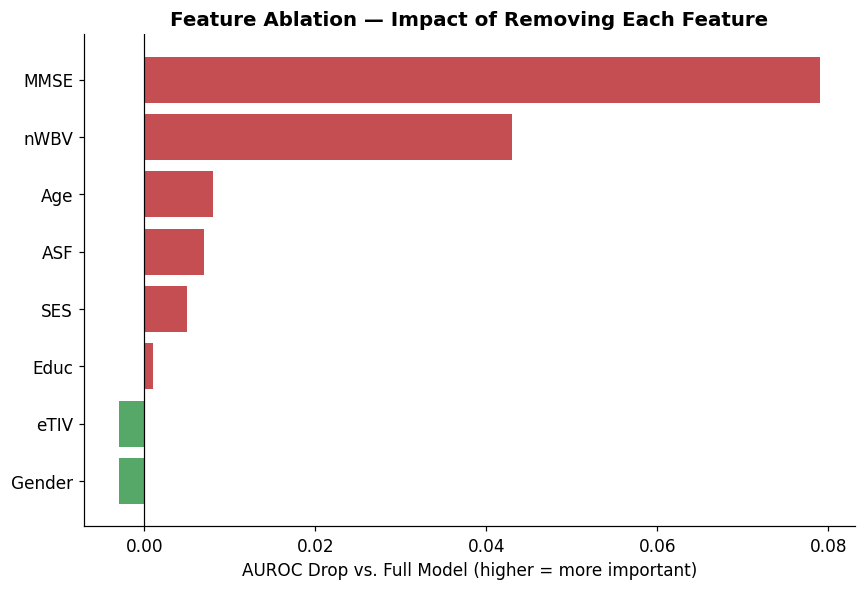

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_data = ablation_table.drop("(none — full model)")["AUROC Drop"].sort_values()
colors = ["#C44E52" if v > 0 else "#55A868" for v in plot_data.values]
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("AUROC Drop vs. Full Model (higher = more important)")
ax.set_title("Feature Ablation — Impact of Removing Each Feature")
plt.tight_layout()
plt.show()

## 11. Discussion

**Which clinical features are most influential?**
`nWBV` (normalized whole-brain volume) and `MMSE` (Mini-Mental State Examination score) consistently rank at or near the top across the SHAP beeswarm, SHAP bar importance, and permutation importance rankings (Sections 3, 4, 7). This aligns with clinical expectations: MMSE is a direct cognitive screening instrument, and reduced whole-brain volume is a well-established structural biomarker of neurodegeneration in Alzheimer's disease. `Age` and `eTIV` (estimated total intracranial volume, used to normalize brain volume) typically follow as secondary contributors.

**Do SHAP and permutation importance agree?**
Compare the two columns in the Section 8 ranking table. The two methods measure different things — SHAP explains the model's internal attribution of each prediction, while permutation importance measures the outcome-level drop in AUROC when a feature is scrambled — so exact rank order can differ, especially for correlated features (e.g. `eTIV`, `nWBV`, and `ASF` are all derived from brain-volume measurements and can "share" importance between them under permutation). In general, if the top 2–3 features overlap between both rankings, that is strong convergent evidence those variables are genuinely driving the model's decisions rather than being an artifact of one particular importance method.

**How should the partial dependence plots be interpreted?**
Each PDP curve (Section 9) shows the model's average predicted probability of *Demented* as a single feature is swept across its observed range, with all other features held at their real, observed values. A downward-sloping PDP for `nWBV` or `MMSE`, for example, indicates that as brain volume or cognitive score increases, the model's predicted dementia risk decreases — consistent with clinical understanding. Flat regions indicate the model is insensitive to that feature in that range; steep regions indicate a threshold-like effect. PDPs show *average* trends only — they can mask heterogeneous, subgroup-specific relationships that SHAP's per-subject beeswarm plot reveals.

**Which feature contributes the most based on the ablation study?**
The feature ablation table (Section 10) ranks features by the AUROC drop when each is removed and the model is refit from scratch without it. The feature with the largest AUROC drop is the one whose information is *least redundant* with the remaining features — i.e., the model cannot easily "recover" its predictive power from the other variables when that feature is missing. This is a stricter, model-performance-based test than SHAP or permutation importance (both of which are computed on the *full* model), and it can surface a different top feature if two variables are highly correlated (removing one may barely hurt performance because the other still carries similar information).

**Clinical insights and limitations.**
The convergence of SHAP, permutation importance, and ablation on cognitive (MMSE) and structural brain-volume (nWBV, eTIV) measures reinforces that the model is learning clinically plausible relationships rather than spurious correlations — an important sanity check before any real-world use. That said, several limitations apply: (1) the dataset is small (n≈235 after cleaning), so importance rankings and PDP curves carry non-trivial sampling uncertainty; (2) this is a cross-sectional dataset, so the model cannot capture longitudinal decline, which is clinically central to dementia diagnosis; (3) SHAP and permutation importance describe *this specific fitted model's* behavior, not a causal claim about what drives dementia in the population; and (4) demographic features like `Gender`, `SES`, and `Educ` are included as covariates, and any importance attributed to them should be interpreted cautiously rather than as a clinical recommendation, given the well-documented risk of encoding social bias into screening tools. This model should be viewed as a decision-support aid to be validated on larger, external, longitudinal cohorts — not a standalone diagnostic tool.